In [1]:
import xarray as xr

In [16]:
sal = xr.open_mfdataset('sal/sal_*', chunks={"depth": 1}).isel(depth=0)
sal

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 1205, latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-09-17
Data variables:
    so         (time, latitude, longitude) float32 7GB dask.array<chunksize=(30, 1201, 1201), meta=np.ndarray>
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    Conventions:               CF-1.8
    copernicusmarine_version:  2.2.0

In [14]:
sal5 = sal.resample(time="5D").mean()
# sal5c = sal5.chunk({'time': -1, 'latitude': -1, 'longitude': -1})
# sal5.compute().to_netcdf('sal5.nc')
sal5

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 241, latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 2kB 2022-06-01 2022-06-06 ... 2025-09-13
Data variables:
    so         (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 1201, 1201), meta=np.ndarray>
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    Conventions:               CF-1.8
    copernicusmarine_version:  2.2.0

In [15]:
sal5 = sal5.compute()
sal5

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 241, latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 2kB 2022-06-01 2022-06-06 ... 2025-09-13
Data variables:
    so         (time, latitude, longitude) float32 1GB 34.16 34.17 ... 34.45
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    Conventions:               CF-1.8
    copernicusmarine_version:  2.2.0

In [ ]:
# import dask

# encoding = {v: {'zlib': True, 'complevel': 1, 'shuffle': True}
#             for v in sal5c.data_vars}

# sal5c.to_netcdf('sal5.nc', engine='netcdf4', encoding=encoding, compute=True)
# sal5.to_zarr('sal5.zarr', mode='w')
# sal10.to_netcdf("sal10.nc")

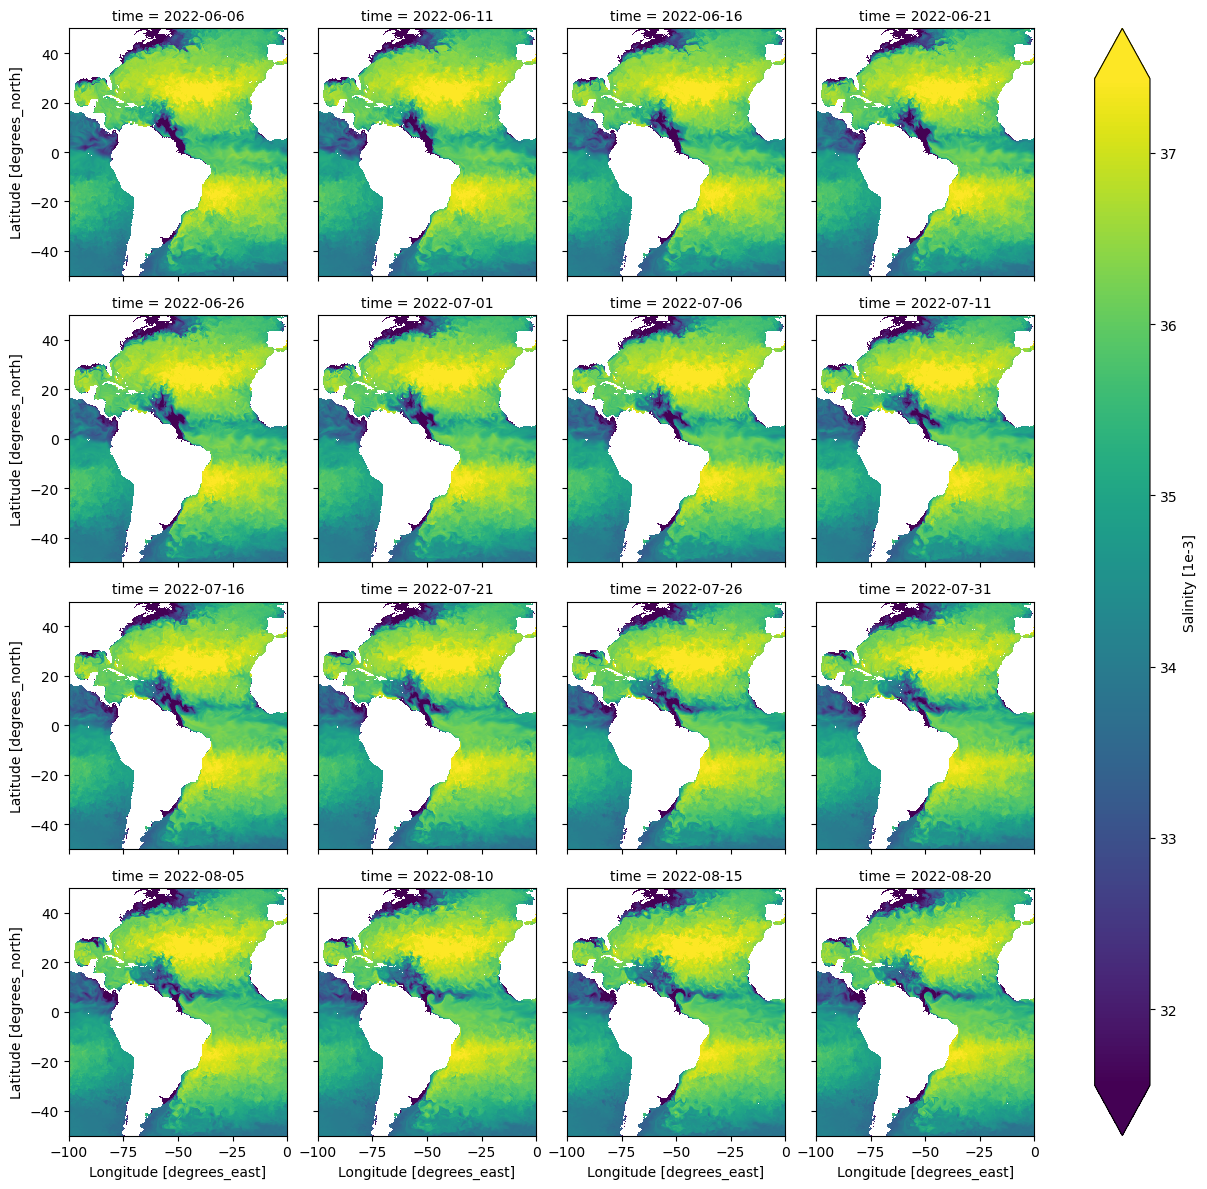

In [4]:
sal5.so.isel(time=slice(None,16)).plot(col='time',col_wrap=4, robust=True)
plt.show()

### Temperature

In [ ]:
t = xr.open_mfdataset('temp/temp_*').isel(depth=0)
t

## Videos for plume particle description

In [ ]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

# 1) Open dataset (skip if already open)
# ds = xr.open_dataset('path_to_your_file.nc')  # has variable 'so'

da = sal5['so']  # salinity (time, latitude, longitude)
lat = sal5['latitude']; lon = sal5['longitude']

# 2) Choose a time range (optional: keep all)
da = da.sel(time=slice('2024-03-01', '2024-04-25'))

# 3) Output folder
outdir = 'frames'
os.makedirs(outdir, exist_ok=True)

# 4) Consistent color scale (pick robust range once)
vmin = float(da.quantile(0.02).compute())
vmax = float(da.quantile(0.98).compute())

# 5) Render each frame
proj = ccrs.PlateCarree()
extent = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]

for i, t in enumerate(da['time'].values):
    frame = da.sel(time=t)
    fig, ax = plt.subplots(figsize=(8, 4.5), subplot_kw={'projection': proj})
    pm = frame.plot(
        x='longitude', y='latitude',
        ax=ax, transform=proj,
        cmap='viridis_r', vmin=vmin, vmax=vmax,
        add_colorbar=True
    )
    ax.coastlines(resolution='110m', linewidth=0.6)
    ax.add_feature(cf.BORDERS, linewidth=0.3)
    ax.add_feature(cf.LAND, facecolor='#8e9497ff', edgecolor='none')
    ax.set_extent(extent, crs=proj)

    # Title
    ax.set_title(f"Salinity (so), {np.datetime_as_string(t, unit='D')}")
    fig.tight_layout()

    fname = os.path.join(outdir, f"frame_{i:04d}.png")
    plt.savefig(fname, dpi=150)
    plt.close(fig)

print(f"Saved frames to {outdir}/")